In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense,Dropout
import json
import glob

# Load all JSON files
json_files = glob.glob('*.json')
all_samples = []

for file in json_files:
    with open(file, "r") as f:
        raw = json.load(f)
    
    if isinstance(raw, list):
        for session in raw:
            samples = session['samples']
            all_samples.extend(samples)
    else:
        samples = raw['samples']
        all_samples.extend(samples)

print(f"Total samples: {len(all_samples)}")
# Extract samples
df_data = pd.DataFrame(all_samples)
df = pd.json_normalize(all_samples)

print(df_data.columns.tolist())
df_data.set_index('time', inplace=True)
print(df_data.head())

Total samples: 124696
['time', 'env', 'trial', 'user', 'pois']
       env  trial                                               user  \
time                                                                   
9303.7   D      1  {'x': -0.009576471146144114, 'z': -0.020370276...   
9354.3   D      1  {'x': -0.008997241417596447, 'z': -0.020436469...   
9403.6   D      1  {'x': -0.00861159972056974, 'z': -0.0201739579...   
9455.3   D      1  {'x': -0.008545451095556864, 'z': -0.020026871...   
9503.7   D      1  {'x': -0.008380717327506847, 'z': -0.019520434...   

                                                     pois  
time                                                       
9303.7  [{'distance': 1.253272932899953, 'angle': 1.21...  
9354.3  [{'distance': 1.253799755449084, 'angle': 1.21...  
9403.6  [{'distance': 1.2542495012332384, 'angle': 1.2...  
9455.3  [{'distance': 1.2543596089658189, 'angle': 1.2...  
9503.7  [{'distance': 1.2546791690551167, 'angle': 1.2...  


In [35]:
# Filter valid samples
df_data = df_data[df_data['user'].apply(lambda x: isinstance(x, dict)) & df_data['pois'].apply(lambda x: isinstance(x, list))]
print(f"Filtered data length: {len(df_data)}")

Filtered data length: 124696


In [36]:
print(df_data['user'].apply(type).value_counts())
print(df_data['pois'].apply(type).value_counts())

user
<class 'dict'>    124696
Name: count, dtype: int64
pois
<class 'list'>    124696
Name: count, dtype: int64


In [37]:
print(df_data.columns)

Index(['env', 'trial', 'user', 'pois'], dtype='str')


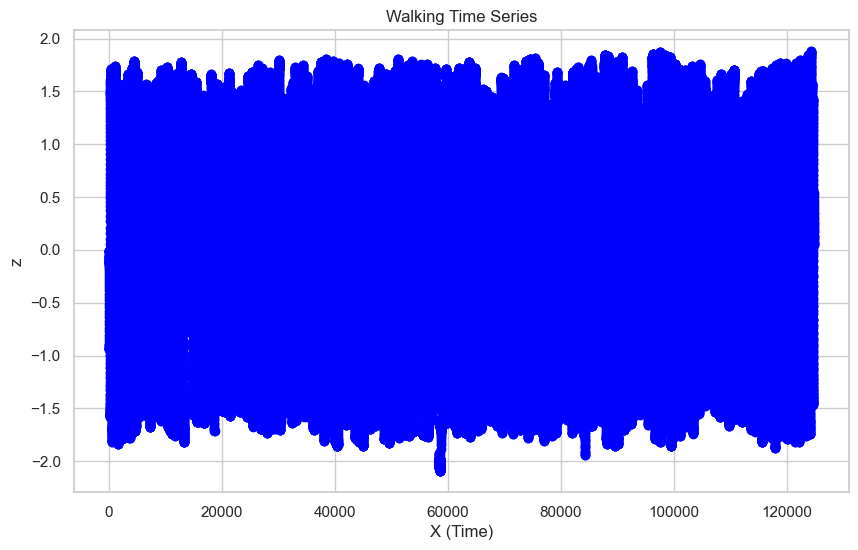

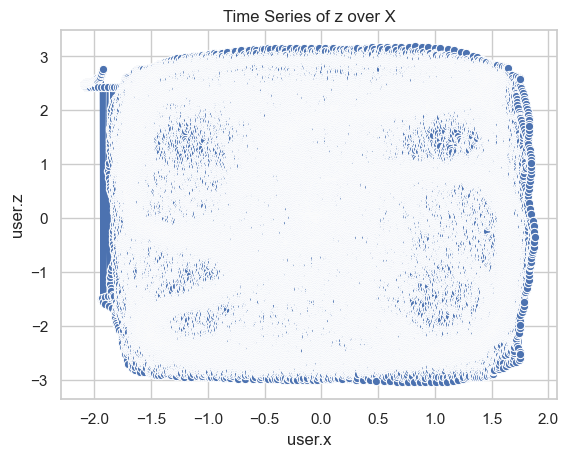

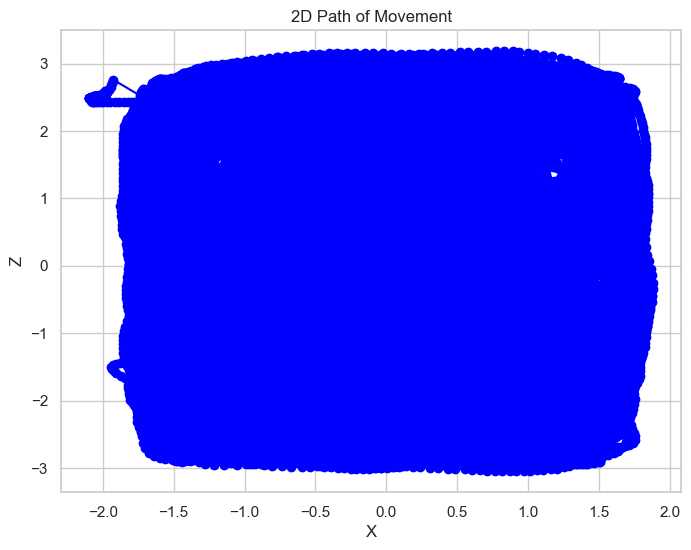

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(df['user.x'], marker='o', linestyle='-',color='blue')
plt.title('Walking Time Series')
plt.xlabel('X (Time)')
plt.ylabel('z')
plt.grid(True)
plt.show()

sns.set(style="whitegrid")
sns.lineplot(x='user.x', y='user.z', data=df, marker='o')
plt.title('Time Series of z over X')
plt.show()

fig = px.line(df, x='user.x', y='user.z', title='Interactive Time Series of z over X')

fig.update_layout(
    xaxis_title='X (Time)',
    yaxis_title='z',
    template='plotly_white'
)

fig.show()

# Plot path
plt.figure(figsize=(8, 6))
plt.plot(df['user.x'], df['user.z'], marker='o', linestyle='-', color='blue')
plt.title('2D Path of Movement')
plt.xlabel('X')
plt.ylabel('Z')
plt.grid(True)
plt.show()

plt.show()

In [39]:
# Flatten user
print(f"df_data len: {len(df_data)}")
user_df = pd.json_normalize(df_data['user'])
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']
print(f"user_df len: {len(user_df)}")
# user_df['env'] = data['env']
# user_df['trial'] = data['trial']
# user_df['time'] = data['time']

df_data len: 124696
user_df len: 124696


In [40]:
# Flatten POIs with relative angles
# Extract yaw for relative angles
yaw_series = df_data['user'].apply(lambda x: x['yaw'])

def flatten_pois_safe(row, yaw, max_pois=5):
    pois_list = row
    
    # Handle bad rows
    if not isinstance(pois_list, list):
        return {f'poi_{i}_{k}': 0 for i in range(max_pois) for k in ['dist', 'angle']}
    
    # Sort by distance
    pois_list = sorted(pois_list, key=lambda x: x['distance'])
    
    flat = {}
    
    for i in range(max_pois):
        if i < len(pois_list):
            flat[f'poi_{i}_dist'] = pois_list[i]['distance']
            # Compute relative angle and wrap to [-pi, pi]
            rel_angle = pois_list[i]['angle'] - yaw
            flat[f'poi_{i}_angle'] = np.arctan2(np.sin(rel_angle), np.cos(rel_angle))
        else:
            flat[f'poi_{i}_dist'] = 0
            flat[f'poi_{i}_angle'] = 0
    
    return flat

pois_df = pd.DataFrame([flatten_pois_safe(p, y) for p, y in zip(df_data['pois'], yaw_series)])


In [41]:
# Flatten user
user_df = pd.json_normalize(df_data['user'])
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']

In [42]:
print(type(df_data['pois'].iloc[0]))
print(df_data['pois'].iloc[0])

<class 'list'>
[{'distance': 1.253272932899953, 'angle': 1.2139552903169568}, {'distance': 1.9673928533215423, 'angle': 0.7034945170166381}, {'distance': 2.309717385714271, 'angle': 0.848629759227636}, {'distance': 2.525997930279281, 'angle': 0.5762463016909609}, {'distance': 2.9614143598956626, 'angle': 0.07653475677376848}]


In [43]:
print(pois_df.head())

   poi_0_dist  poi_0_angle  poi_1_dist  poi_1_angle  poi_2_dist  poi_2_angle  \
0    1.253273     1.185671    1.967393     0.675210    2.309717     0.820345   
1    1.253800     1.184771    1.967730     0.674457    2.310120     0.819494   
2    1.254250     1.183313    1.968183     0.673199    2.310584     0.818182   
3    1.254360     1.182320    1.968337     0.672288    2.310729     0.817261   
4    1.254679     1.174390    1.968824     0.664665    2.311180     0.809596   

   poi_3_dist  poi_3_angle  poi_4_dist  poi_4_angle  
0    2.525998     0.547962    2.961414     0.048250  
1    2.526272     0.547218    2.961401     0.049045  
2    2.526707     0.545990    2.961698     0.048590  
3    2.526866     0.545098    2.961850     0.047982  
4    2.527376     0.537561    2.962370     0.042400  


In [44]:
# Combine (use index as time)
df_final = pd.concat([
    df_data.reset_index()[['time', 'env', 'trial']].reset_index(drop=True),
    user_df.reset_index(drop=True),
    pois_df.reset_index(drop=True)
], axis=1)

df_final = df_final.dropna()

print(f"Lengths: df_data {len(df_data)}, user_df {len(user_df)}, pois_df {len(pois_df)}, df_final {len(df_final)}")
print(df_final['env'].value_counts())
print(df.head())

Lengths: df_data 124696, user_df 124696, pois_df 124696, df_final 124696
env
D    45835
C    30008
B    24793
A    24060
Name: count, dtype: int64
     time env  trial                                               pois  \
0  9303.7   D      1  [{'distance': 1.253272932899953, 'angle': 1.21...   
1  9354.3   D      1  [{'distance': 1.253799755449084, 'angle': 1.21...   
2  9403.6   D      1  [{'distance': 1.2542495012332384, 'angle': 1.2...   
3  9455.3   D      1  [{'distance': 1.2543596089658189, 'angle': 1.2...   
4  9503.7   D      1  [{'distance': 1.2546791690551167, 'angle': 1.2...   

     user.x    user.z   user.vx   user.vz  user.yaw  
0 -0.009576 -0.020370  0.014867 -0.005156  0.028285  
1 -0.008997 -0.020436  0.011447 -0.001308  0.028859  
2 -0.008612 -0.020174  0.007822  0.005325  0.029549  
3 -0.008545 -0.020027  0.001279  0.002845  0.030001  
4 -0.008381 -0.019520  0.003404  0.010464  0.033816  


In [45]:
# Splitting by environment
test_env = 'A'

train_df = df_final[df_final['env'] != test_env]
test_df  = df_final[df_final['env'] == test_env]

In [46]:
print(df_final['env'].value_counts())

env
D    45835
C    30008
B    24793
A    24060
Name: count, dtype: int64


In [47]:
# # Scaling the data for LSTM
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(df)

In [48]:
# Create sequences for LSTM
def create_sequences_grouped(df, seq_length=10):
    X, y = [], []
    
    for _, group in df.groupby(['env', 'trial']):
        
        group = group.reset_index(drop=True)
        
        # Drop non-feature columns
        features = group.drop(columns=['env', 'trial', 'time']).values
        
        for i in range(len(features) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(features[i+seq_length][:2])  # predict x, z
    
    return np.array(X), np.array(y)

In [49]:
# Create sequences
SEQ_LENGTH = 50
X_train, y_train = create_sequences_grouped(train_df, seq_length=SEQ_LENGTH)
X_test, y_test = create_sequences_grouped(test_df, seq_length=SEQ_LENGTH)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (98386, 50, 15), y_train shape: (98386, 2)
X_test shape: (23310, 50, 15), y_test shape: (23310, 2)


In [50]:
# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(SEQ_LENGTH, 15),return_sequences=True),
    LSTM(64, input_shape=(SEQ_LENGTH, 15)),
    Dropout(0.3),
    # Dense(32, activation='relu'),
    Dense(2)
])

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='mse'
)

model.summary()

c:\Users\JetPa\anaconda3\envs\mnist_tf2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 50, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,634 (209.51 KB)

 Trainable params: 53,634 (209.51 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Train the model
model.fit(
    X_train, y_train,
    epochs=20, #100 please
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 119s 73ms/step - loss: 0.1114 - val_loss: 0.0406
Epoch 2/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 0.0502 - val_loss: 0.0310
Epoch 3/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 0.0457 - val_loss: 0.0273
Epoch 4/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - loss: 0.0445 - val_loss: 0.0275
Epoch 5/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - loss: 0.0441 - val_loss: 0.0255
Epoch 6/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 0.0435 - val_loss: 0.0254
Epoch 7/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 0.0428 - val_loss: 0.0240
Epoch 8/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - loss: 0.0421 - val_loss: 0.0245
Epoch 9/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - loss: 0.0417 - val_loss: 0.0240
Epoch 10/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - loss: 0.0417 - val_loss: 0.0240
Epoch 11/100
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - loss: 0.0412 - val_loss: 0.0

KeyboardInterrupt: 

In [ ]:
# make predictions
preds = model.predict(X_test)

 99/729 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

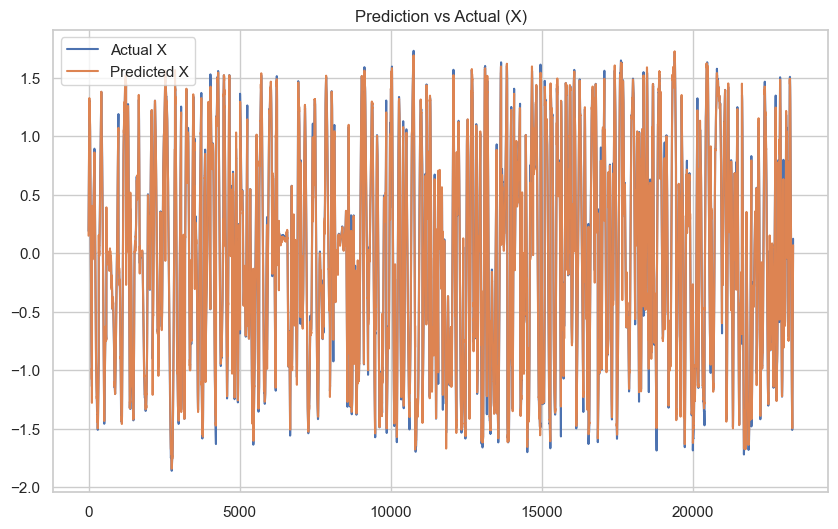

In [ ]:
# Plot actual vs predicted for X
plt.figure(figsize=(10,6))

# Actual
plt.plot(y_test[:,0], label='Actual X')
# Predicted
plt.plot(preds[:,0], label='Predicted X')

plt.legend()
plt.title("Prediction vs Actual (X)")
plt.show()

In [55]:
# Select one trial from environment D
selected_trial = test_df['trial'].unique()[0]
test_df_single = test_df[test_df['trial'] == selected_trial]

# Create sequences for this single trial
X_test_single, y_test_single = create_sequences_grouped(test_df_single, seq_length=SEQ_LENGTH)

# Get actual positions
actual_x = test_df_single['x'].values
actual_z = test_df_single['z'].values

# Calculate POI positions (at the user's position when closest to each POI)
poi_x_list = []
poi_z_list = []
for poi in range(5):
    dist_col = f'poi_{poi}_dist'
    min_dist_idx = test_df_single[dist_col].idxmin()
    poi_x = test_df_single.loc[min_dist_idx, 'x']
    poi_z = test_df_single.loc[min_dist_idx, 'z']
    poi_x_list.append(poi_x)
    poi_z_list.append(poi_z)

poi_positions = list(zip(poi_x_list, poi_z_list))

# Predict next 20 timesteps for each timestep with stride 5
stride = 5
predicted_paths = []

for start_idx in range(0, len(X_test_single), stride):
    start_seq = X_test_single[start_idx].copy()
    predictions = []
    current_seq = start_seq.copy()
    
    for _ in range(20):
        pred = model.predict(current_seq.reshape(1, SEQ_LENGTH, 15), verbose=0)[0]  # [x, z]
        predictions.append(pred)
        
        # Create new timestep features
        prev_x, prev_z = current_seq[-1, 0], current_seq[-1, 1]
        new_x, new_z = pred
        new_vx = new_x - prev_x  # Assume dt=1
        new_vz = new_z - prev_z
        new_yaw = current_seq[-1, 4]  # Keep yaw the same
        
        # Recalculate POI features
        poi_features = []
        for px, pz in poi_positions:
            dist = np.sqrt((new_x - px)**2 + (new_z - pz)**2)
            angle = np.arctan2(pz - new_z, px - new_x)
            rel_angle = angle - new_yaw
            rel_angle = np.arctan2(np.sin(rel_angle), np.cos(rel_angle))
            poi_features.extend([dist, rel_angle])
        
        new_timestep = [new_x, new_z, new_vx, new_vz, new_yaw] + poi_features
        
        # Shift sequence: remove first, add new
        current_seq = np.roll(current_seq, -1, axis=0)
        current_seq[-1] = new_timestep
    
    # Starting position for this prediction
    start_x = start_seq[-1, 0]
    start_z = start_seq[-1, 1]
    pred_path_x = [start_x] + [p[0] for p in predictions]
    pred_path_z = [start_z] + [p[1] for p in predictions]
    predicted_paths.append((pred_path_x, pred_path_z))

# Plot interactive map
import plotly.graph_objects as go

fig = go.Figure()

# Add actual path
fig.add_trace(go.Scatter(x=actual_x, y=actual_z, mode='lines+markers', name='Actual Path', 
                         line=dict(color='blue', width=2), marker=dict(size=4)))

# Add start and end markers
fig.add_trace(go.Scatter(x=[actual_x[0]], y=[actual_z[0]], mode='markers', name='Start', 
                         marker=dict(color='green', size=10, symbol='star')))
fig.add_trace(go.Scatter(x=[actual_x[-1]], y=[actual_z[-1]], mode='markers', name='End', 
                         marker=dict(color='purple', size=10, symbol='star')))

# Add predicted paths
colors = ['red', 'orange', 'yellow', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
for idx, (pred_x, pred_z) in enumerate(predicted_paths):
    color = colors[idx % len(colors)]
    fig.add_trace(go.Scatter(x=pred_x, y=pred_z, mode='lines+markers', 
                             name=f'Predicted from step {idx*stride}', 
                             line=dict(color=color, width=2, dash='dash'), 
                             marker=dict(size=3, color=color), showlegend=True))

# Add POIs
fig.add_trace(go.Scatter(x=poi_x_list, y=poi_z_list, mode='markers', name='POIs', 
                         marker=dict(color='black', size=8, symbol='x')))

fig.update_layout(
    title=f'Map of Actual and Predicted User Walking Paths (Environment D, Trial {selected_trial})',
    xaxis_title='X Position',
    yaxis_title='Z Position',
    width=800,
    height=600
)

fig.show()

In [56]:
# Evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_x = mean_absolute_error(y_test[:, 0], preds[:, 0])
mae_z = mean_absolute_error(y_test[:, 1], preds[:, 1])
rmse_x = np.sqrt(mean_squared_error(y_test[:, 0], preds[:, 0]))
rmse_z = np.sqrt(mean_squared_error(y_test[:, 1], preds[:, 1]))

print(f"Test MAE - X: {mae_x:.4f}, Z: {mae_z:.4f}")
print(f"Test RMSE - X: {rmse_x:.4f}, Z: {rmse_z:.4f}")

# Overall MAE and RMSE
mae_overall = (mae_x + mae_z) / 2
rmse_overall = (rmse_x + rmse_z) / 2
print(f"Overall MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}")

Test MAE - X: 0.0314, Z: 0.0451
Test RMSE - X: 0.0944, Z: 0.1897
Overall MAE: 0.0382, RMSE: 0.1420


POI Distance Statistics:
          poi_0_dist     poi_1_dist     poi_2_dist     poi_3_dist  \
count  124696.000000  124696.000000  124696.000000  124696.000000   
mean        1.768782       1.888825       1.673824       1.397782   
std         1.072724       1.460316       1.715956       1.892210   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.975733       0.000000       0.000000       0.000000   
50%         1.498347       1.943795       1.807432       0.000000   
75%         2.267092       2.851407       3.076783       3.144517   
max         6.266718       6.181635       6.536422       6.356879   

          poi_4_dist  
count  124696.000000  
mean        0.912138  
std         1.800514  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         6.431860  

POI Angle Statistics:
         poi_0_angle    poi_1_angle    poi_2_angle    poi_3_angle  \
count  124696.000000  124696.000000  124696.000000  12

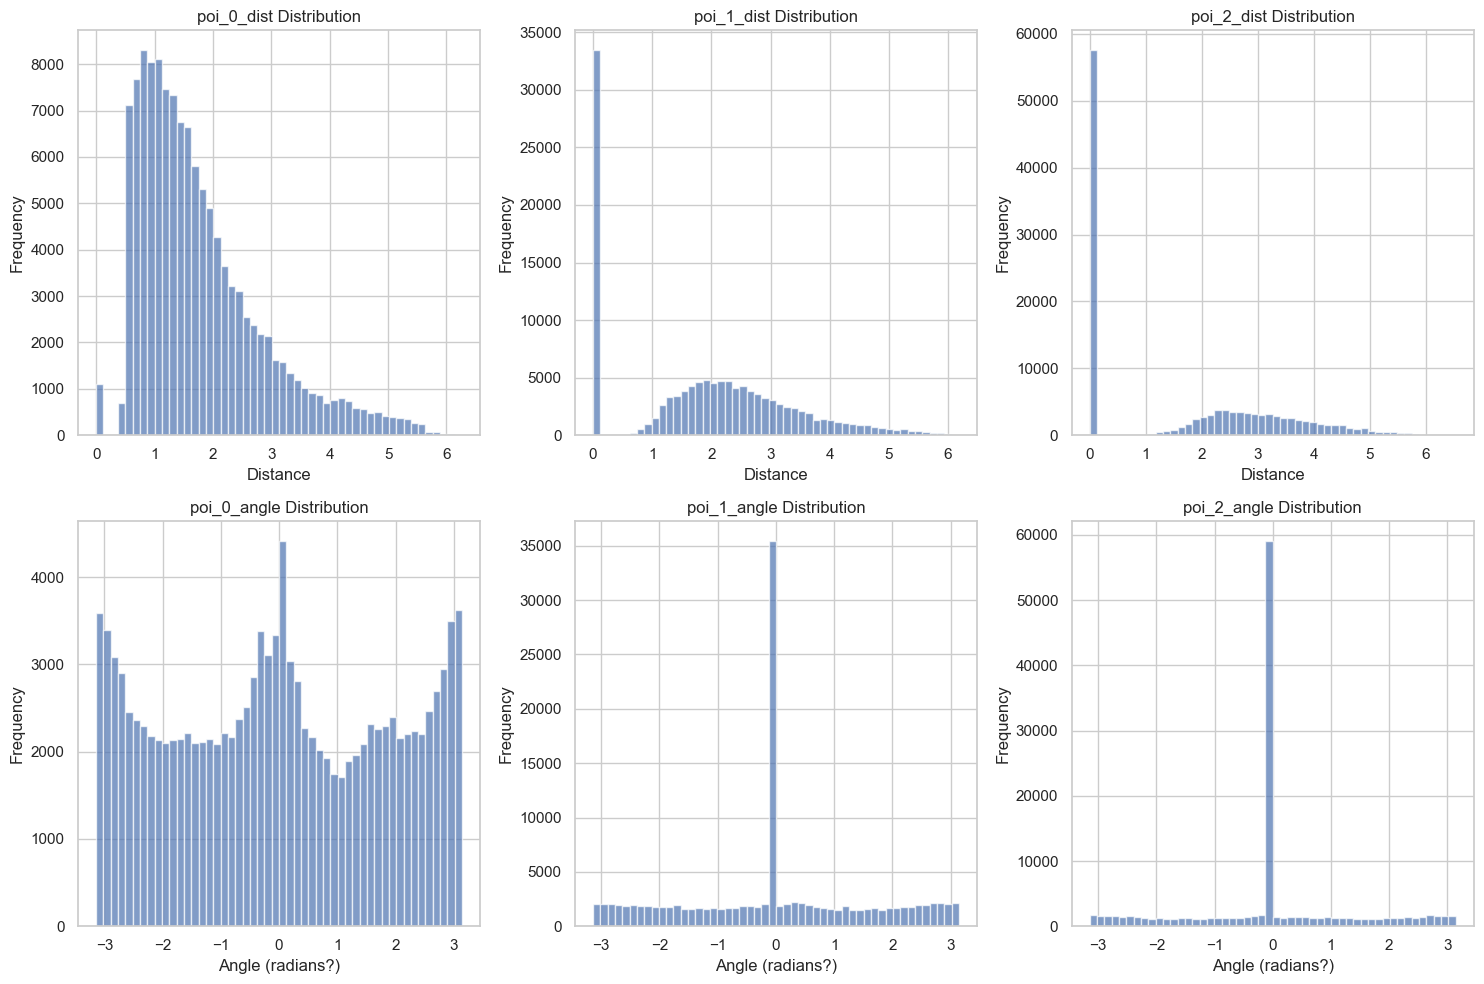


Sample angles: 0    1.185671
1    1.184771
2    1.183313
3    1.182320
4    1.174390
Name: poi_0_angle, dtype: float64
Yaw range: -3.142 to 3.142
Angle range: -3.142 to 3.142


In [ ]:
# Analyze POI data validity
import matplotlib.pyplot as plt

poi_cols = [col for col in df_final.columns if 'poi' in col and 'dist' in col]
angle_cols = [col for col in df_final.columns if 'poi' in col and 'angle' in col]

print("POI Distance Statistics:")
print(df_final[poi_cols].describe())

print("\nPOI Angle Statistics:")
print(df_final[angle_cols].describe())

# Check correlation between yaw and angles
yaw_col = 'yaw'
corrs_yaw = df_final[[yaw_col] + angle_cols].corr()
print(f"\nCorrelations between yaw and POI angles:\n{corrs_yaw[yaw_col]}")

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(poi_cols[:3]):
    axes[0, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[0, i].set_title(f'{col} Distribution')
    axes[0, i].set_xlabel('Distance')
    axes[0, i].set_ylabel('Frequency')

for i, col in enumerate(angle_cols[:3]):
    axes[1, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[1, i].set_title(f'{col} Distribution')
    axes[1, i].set_xlabel('Angle (radians?)')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check if angles are in degrees or radians
print(f"\nSample angles: {df_final[angle_cols[0]].head()}")
print(f"Yaw range: {df_final[yaw_col].min():.3f} to {df_final[yaw_col].max():.3f}")
print(f"Angle range: {df_final[angle_cols[0]].min():.3f} to {df_final[angle_cols[0]].max():.3f}")

In [ ]:
# Check correlations between POI features and target positions
poi_cols = [col for col in df_final.columns if 'poi' in col]
target_cols = ['x', 'z']

corrs = df_final[poi_cols + target_cols].corr()
print("Correlations between POI features and positions:")
print(corrs.loc[poi_cols, target_cols])

# Also check with velocities and yaw
all_features = ['x', 'z', 'vx', 'vz', 'yaw'] + poi_cols
corrs_full = df_final[all_features].corr()
print("\nFull feature correlations with x and z:")
print(corrs_full.loc[all_features, ['x', 'z']])

# Check if POI features have predictive power
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Simple linear regression for each POI feature to x
for col in poi_cols:
    X_feat = df_final[[col]]
    y_x = df_final['x']
    model_x = LinearRegression().fit(X_feat, y_x)
    r2_x = r2_score(y_x, model_x.predict(X_feat))
    
    y_z = df_final['z']
    model_z = LinearRegression().fit(X_feat, y_z)
    r2_z = r2_score(y_z, model_z.predict(X_feat))
    
    print(f"{col}: R² with x = {r2_x:.4f}, with z = {r2_z:.4f}")

Correlations between POI features and positions:
                    x         z
poi_0_dist   0.018859  0.032302
poi_0_angle -0.008243 -0.051682
poi_1_dist   0.028092 -0.052404
poi_1_angle  0.090252 -0.058654
poi_2_dist   0.028564 -0.074902
poi_2_angle  0.062897 -0.054794
poi_3_dist   0.005125 -0.053141
poi_3_angle  0.044812 -0.037905
poi_4_dist  -0.015937 -0.004264
poi_4_angle  0.033487 -0.044720

Full feature correlations with x and z:
                    x         z
x            1.000000  0.031384
z            0.031384  1.000000
vx           0.021279 -0.058205
vz           0.078312  0.021154
yaw          0.223453  0.017073
poi_0_dist   0.018859  0.032302
poi_0_angle -0.008243 -0.051682
poi_1_dist   0.028092 -0.052404
poi_1_angle  0.090252 -0.058654
poi_2_dist   0.028564 -0.074902
poi_2_angle  0.062897 -0.054794
poi_3_dist   0.005125 -0.053141
poi_3_angle  0.044812 -0.037905
poi_4_dist  -0.015937 -0.004264
poi_4_angle  0.033487 -0.044720
poi_0_dist: R² with x = 0.0004, with z = 0.001

In [ ]:
# Train a baseline model without POI features
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Features without POIs: x, z, vx, vz, yaw (5 features)
X_train_no_poi = X_train[:, :, :5]
X_test_no_poi = X_test[:, :, :5]

model_no_poi = Sequential([
    LSTM(64, input_shape=(SEQ_LENGTH, 15),return_sequences=True),
    LSTM(64, input_shape=(SEQ_LENGTH, 15)),
    Dropout(0.3),
    # Dense(32, activation='relu'),
    Dense(2)
])


model_no_poi.compile(optimizer=optimizer, loss='mse')

print("Training model without POI features...")
history_no_poi = model_no_poi.fit(
    X_train_no_poi, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_no_poi, y_test),
    verbose=0
)

preds_no_poi = model_no_poi.predict(X_test_no_poi)

mae_x_no_poi = mean_absolute_error(y_test[:, 0], preds_no_poi[:, 0])
mae_z_no_poi = mean_absolute_error(y_test[:, 1], preds_no_poi[:, 1])
rmse_x_no_poi = np.sqrt(mean_squared_error(y_test[:, 0], preds_no_poi[:, 0]))
rmse_z_no_poi = np.sqrt(mean_squared_error(y_test[:, 1], preds_no_poi[:, 1]))

print(f"Model without POIs - MAE X: {mae_x_no_poi:.4f}, Z: {mae_z_no_poi:.4f}")
print(f"Model without POIs - RMSE X: {rmse_x_no_poi:.4f}, Z: {rmse_z_no_poi:.4f}")

print(f"\nComparison:")
print(f"With POIs - MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}")
print(f"Without POIs - MAE: {(mae_x_no_poi + mae_z_no_poi)/2:.4f}, RMSE: {(rmse_x_no_poi + rmse_z_no_poi)/2:.4f}")

# Check if POIs improve performance
if mae_overall < (mae_x_no_poi + mae_z_no_poi)/2:
    print("POI features improve model performance.")
else:
    print("POI features do not improve (or worsen) model performance.")

Training model without POI features...


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 5 and 15 for '{{node sequential_5_1/lstm_9_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_5_1/lstm_9_1/strided_slice_2, sequential_5_1/lstm_9_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [?,5], [15,256].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(None, 5), dtype=float32)
  • states=('tf.Tensor(shape=(None, 64), dtype=float32)', 'tf.Tensor(shape=(None, 64), dtype=float32)')
  • training=True

In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[]
